<a href="https://colab.research.google.com/github/alejitovm97-byte/Alejo-Varelas-projects/blob/main/02_HRP_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# NB02 v3 — HRP Portfolio Backtest
# ============================================================
# CELDA 0.1 — Librerías y configuración
# ============================================================
import numpy as np
import pandas as pd
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from datetime import datetime

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

# --- Versión y cambios ---
VERSION = 'v3'
CHANGES = """
NB02 v3 — Cambios respecto a v2:
  1. HRP 100% puro: sin cap, sin threshold
  2. Delisted intra-trimestre: reemplazo inmediato con #51 del ranking
  3. Sección pedagógica HRP expandida (visualizaciones paso a paso)
  4. EW benchmark con rebalanceo trimestral (comparación justa)
  5. Tabla retorno bruto vs neto (post-costos)
  6. Test estadístico de diferencia de Sharpe
  7. Descomposición de turnover (universo vs pesos)
  8. UCITS 5/10/40 como robustness check (Sección 9)
"""

print(f"NB02 {VERSION} — HRP Portfolio Backtest")
print(f"{'='*50}")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")
print(f"Ejecución: {datetime.today().strftime('%Y-%m-%d %H:%M')}")
print(CHANGES)

NB02 v3 — HRP Portfolio Backtest
NumPy: 2.0.2 | Pandas: 2.2.2
Ejecución: 2026-04-12 14:25

NB02 v3 — Cambios respecto a v2:
  1. HRP 100% puro: sin cap, sin threshold
  2. Delisted intra-trimestre: reemplazo inmediato con #51 del ranking
  3. Sección pedagógica HRP expandida (visualizaciones paso a paso)
  4. EW benchmark con rebalanceo trimestral (comparación justa)
  5. Tabla retorno bruto vs neto (post-costos)
  6. Test estadístico de diferencia de Sharpe
  7. Descomposición de turnover (universo vs pesos)
  8. UCITS 5/10/40 como robustness check (Sección 9)



In [ ]:
# ============================================================
# CELDA 0.2 — Parámetros globales
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# --- Rutas ---
BASE_PATH = '/content/drive/MyDrive/TFM/'
DATA_PATH = BASE_PATH + 'Datos/'
OUT_PATH  = BASE_PATH + 'outputs/'

# --- Universo ---
TOP_N = 50

# --- Covarianza ---
WINDOW = 504                   # ~2 años de trading days
LINKAGE_METHOD = 'single'      # Paper López de Prado (2016)

# --- HRP puro: sin cap, sin threshold ---
# Constraints eliminados en v3 para preservar la señal del modelo

# --- Costos ---
COST_BP = 0.0010               # 10bp por turnover neto

# --- Backtest ---
BT_START = '2011-04-01'
BT_END   = '2025-12-31'
REBAL_MONTHS = [1, 4, 7, 10]

# --- Benchmarks ---
BENCH_TICKER = '^GSPC'
RF_TICKER    = '^IRX'

# --- Delisting ---
MAX_GAP_DAYS = 5               # >5 días sin cotización = delisted

print("Parámetros globales:")
print(f"  TOP_N:       {TOP_N}")
print(f"  WINDOW:      {WINDOW} días")
print(f"  LINKAGE:     {LINKAGE_METHOD}")
print(f"  CONSTRAINTS: Ninguno (HRP puro)")
print(f"  COST:        {COST_BP*10000:.0f}bp")
print(f"  PERÍODO:     {BT_START} → {BT_END}")
print(f"  DELISTING:   Reemplazo inmediato tras >{MAX_GAP_DAYS} días sin precio")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parámetros globales:
  TOP_N:       50
  WINDOW:      504 días
  LINKAGE:     single
  CONSTRAINTS: Ninguno (HRP puro)
  COST:        10bp
  PERÍODO:     2011-04-01 → 2025-12-31
  DELISTING:   Reemplazo inmediato tras >5 días sin precio


In [ ]:
# ============================================================
# CELDA 0.3 — Carga de datos
# ============================================================

# --- 1. Precios diarios (Refinitiv, descargados en v2) ---
print("1. Precios diarios (Refinitiv)...")
prices = pd.read_csv(DATA_PATH + 'daily_prices_refinitiv_all.csv',
                     index_col=0, parse_dates=True)
prices = prices.sort_index().loc['2008-01-01':BT_END]
print(f"   {prices.shape[1]} RICs × {prices.shape[0]} días "
      f"({prices.index[0].date()} → {prices.index[-1].date()})")

# --- 2. Universos ---
print("\n2. Universos (NB01)...")
universes_raw = {
    'S1_Quality': pd.read_csv(OUT_PATH + 'selected_universe_quality_only.csv'),
    'S2_QM':      pd.read_csv(OUT_PATH + 'selected_universe_quality_momentum.csv'),
    'S3_QVM':     pd.read_csv(OUT_PATH + 'selected_universe_qvm.csv')
}

score_cols = {}
for name, df in universes_raw.items():
    sc = [c for c in df.columns if 'score' in c.lower()][0]
    score_cols[name] = sc
    print(f"   {name}: {df.shape[0]} rows, score = '{sc}'")

# --- 3. Mapeo RIC → sector (para análisis posterior) ---
ric_sector = {}
for df in universes_raw.values():
    for _, row in df.iterrows():
        ric_sector[row['ric']] = row['sector']

# --- 4. Universo top 50 por FY (sin duplicados) ---
print("\n3. Universo top 50 por variante...")
universe_by_year = {}

for name, df in universes_raw.items():
    sc = score_cols[name]
    universe_by_year[name] = {}

    for fy in sorted(df['fiscal_year'].unique()):
        entry_year = fy + 1
        if entry_year < 2011 or entry_year > 2025:
            continue

        ranked = (df[df['fiscal_year'] == fy]
                  .sort_values(sc, ascending=False)
                  .reset_index(drop=True))

        top, seen = [], set()
        for _, row in ranked.iterrows():
            ric = row['ric']
            if ric in prices.columns and ric not in seen:
                top.append(ric)
                seen.add(ric)
            if len(top) == TOP_N:
                break

        universe_by_year[name][fy] = top

    fy_list = sorted(universe_by_year[name].keys())
    print(f"   {name}: FY{fy_list[0]}-FY{fy_list[-1]} ({len(fy_list)} años)")

# --- 5. Ranking extendido (para reemplazos de delisted) ---
# Guardamos hasta el top 75 para tener candidatos de reemplazo
print("\n4. Rankings extendidos (top 75 para reemplazos)...")
extended_ranking = {}

for name, df in universes_raw.items():
    sc = score_cols[name]
    extended_ranking[name] = {}

    for fy in sorted(df['fiscal_year'].unique()):
        entry_year = fy + 1
        if entry_year < 2011 or entry_year > 2025:
            continue

        ranked = (df[df['fiscal_year'] == fy]
                  .sort_values(sc, ascending=False)
                  .reset_index(drop=True))

        ext, seen = [], set()
        for _, row in ranked.iterrows():
            ric = row['ric']
            if ric in prices.columns and ric not in seen:
                ext.append(ric)
                seen.add(ric)
            if len(ext) == 75:
                break

        extended_ranking[name][fy] = ext

    print(f"   {name}: {len(ext)} candidatos por FY")

print(f"\n   Datos cargados OK.")

1. Precios diarios (Refinitiv)...
   590 RICs × 4529 días (2008-01-02 → 2025-12-31)

2. Universos (NB01)...
   S1_Quality: 4573 rows, score = 'score_quality_only'
   S2_QM: 4561 rows, score = 'score_quality_momentum'
   S3_QVM: 4369 rows, score = 'score_qvm'

3. Universo top 50 por variante...
   S1_Quality: FY2010-FY2024 (15 años)
   S2_QM: FY2010-FY2024 (15 años)
   S3_QVM: FY2010-FY2024 (15 años)

4. Rankings extendidos (top 75 para reemplazos)...
   S1_Quality: 75 candidatos por FY
   S2_QM: 75 candidatos por FY
   S3_QVM: 75 candidatos por FY

   Datos cargados OK.


In [ ]:
# ============================================================
# CELDA 1.1 — Retornos diarios + calendario de rebalanceos
# ============================================================

# --- 1. Retornos ---
log_returns    = np.log(prices / prices.shift(1)).iloc[1:]  # Para covarianza
simple_returns = prices.pct_change().iloc[1:]               # Para NAV

print("1. Retornos:")
print(f"   Log: {log_returns.shape} | Simple: {simple_returns.shape}")
print(f"   Rango: {log_returns.index[0].date()} → {log_returns.index[-1].date()}")

# --- 2. Calendario de rebalanceos ---
trading_days = prices.index

def first_trading_day_on_or_after(target_date):
    target = pd.Timestamp(target_date)
    mask = trading_days >= target
    return trading_days[mask][0] if mask.any() else None

rebal_schedule = []

for fy in sorted(universe_by_year['S2_QM'].keys()):
    entry_year = fy + 1
    for month in REBAL_MONTHS:
        cal_year = entry_year + 1 if month == 1 else entry_year
        rebal_date = first_trading_day_on_or_after(f'{cal_year}-{month:02d}-01')
        if rebal_date is None or rebal_date > pd.Timestamp(BT_END):
            continue
        rebal_schedule.append({
            'rebal_date':  rebal_date,
            'fiscal_year': fy,
            'rebal_type':  'ANNUAL' if month == 4 else 'QUARTERLY',
            'quarter':     {4:'Q2', 7:'Q3', 10:'Q4', 1:'Q1'}[month]
        })

rebal_schedule = pd.DataFrame(rebal_schedule).sort_values('rebal_date').reset_index(drop=True)

print(f"\n2. Rebalanceos: {len(rebal_schedule)} "
      f"({(rebal_schedule['rebal_type']=='ANNUAL').sum()} anuales, "
      f"{(rebal_schedule['rebal_type']=='QUARTERLY').sum()} trimestrales)")
print(f"   {rebal_schedule.iloc[0]['rebal_date'].date()} → "
      f"{rebal_schedule.iloc[-1]['rebal_date'].date()}")

# --- 3. Anti look-ahead ---
print(f"\n3. Anti look-ahead:")
for _, row in rebal_schedule.head(4).iterrows():
    lag = (row['rebal_date'] - pd.Timestamp(f"{row['fiscal_year']}-12-31")).days
    print(f"   FY{row['fiscal_year']} → {row['rebal_date'].date()} "
          f"(lag {lag}d {'OK' if lag >= 90 else 'ALERTA'})")

1. Retornos:
   Log: (4528, 590) | Simple: (4528, 590)
   Rango: 2008-01-03 → 2025-12-31

2. Rebalanceos: 59 (15 anuales, 44 trimestrales)
   2011-04-01 → 2025-10-01

3. Anti look-ahead:
   FY2010 → 2011-04-01 (lag 91d OK)
   FY2010 → 2011-07-01 (lag 182d OK)
   FY2010 → 2011-10-03 (lag 276d OK)
   FY2010 → 2012-01-03 (lag 368d OK)


In [ ]:
# ============================================================
# CELDA 1.2 — Universo validado + detección de delisting
# ============================================================

# --- 1. Validar cobertura de precios por rebalanceo ---
validated_universe = {}
replacement_log = []

for variant in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    validated_universe[variant] = {}
    sc = score_cols[variant]

    for _, row in rebal_schedule.iterrows():
        rebal_date = row['rebal_date']
        fy = row['fiscal_year']
        candidates = universe_by_year[variant].get(fy, [])
        if not candidates:
            continue

        avail = log_returns.index[log_returns.index < rebal_date]
        w_dates = avail[-WINDOW:] if len(avail) >= WINDOW else avail
        min_valid = int(len(w_dates) * 0.80)

        validated, seen = [], set()
        for ric in candidates:
            if ric in log_returns.columns and ric not in seen:
                if log_returns.loc[w_dates, ric].notna().sum() >= min_valid:
                    validated.append(ric)
                    seen.add(ric)

        # Completar con ranking extendido si faltan
        if len(validated) < TOP_N:
            for ric in extended_ranking[variant].get(fy, []):
                if len(validated) >= TOP_N:
                    break
                if ric in seen or ric not in log_returns.columns:
                    continue
                if log_returns.loc[w_dates, ric].notna().sum() >= min_valid:
                    validated.append(ric)
                    seen.add(ric)
                    replacement_log.append({
                        'variant': variant, 'date': rebal_date.date(),
                        'fy': fy, 'ric': ric, 'reason': 'insufficient_data'
                    })

        validated_universe[variant][rebal_date] = validated[:TOP_N]

print("1. Universo validado:")
for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    sizes = [len(x) for x in validated_universe[v].values()]
    print(f"   {v}: {len(sizes)} rebalanceos, {min(sizes)}-{max(sizes)} RICs")

# --- 2. Función de detección de delisting intra-trimestre ---
def detect_delistings(rics, prices, start_date, end_date, max_gap=MAX_GAP_DAYS):
    """
    Detecta RICs que dejan de cotizar entre dos rebalanceos.
    Criterio: >max_gap días consecutivos sin precio.

    Returns:
        dict {ric: fecha_delisting} para RICs delisted
    """
    delistings = {}
    period_prices = prices.loc[start_date:end_date, rics]

    for ric in rics:
        series = period_prices[ric]
        if series.isna().all():
            delistings[ric] = start_date
            continue

        # Buscar gaps consecutivos > max_gap
        is_nan = series.isna()
        if not is_nan.any():
            continue

        # Encontrar primer gap largo
        gap_count = 0
        for date, val in is_nan.items():
            if val:
                gap_count += 1
                if gap_count > max_gap:
                    # Fecha de delisting = primer día del gap
                    delist_date = series.index[series.index <= date][-gap_count]
                    delistings[ric] = delist_date
                    break
            else:
                gap_count = 0

    return delistings


def find_replacement(variant, fy, current_rics, delist_date):
    """
    Encuentra el siguiente RIC del ranking extendido que no está
    ya en el portfolio y tiene datos de precio disponibles.
    """
    for ric in extended_ranking[variant].get(fy, []):
        if ric not in current_rics and ric in prices.columns:
            # Verificar que tiene precio en la fecha de reemplazo
            if pd.notna(prices.loc[:delist_date, ric].iloc[-1]):
                return ric
    return None


# --- 3. Test: detectar delistings en todo el backtest (S2_QM) ---
print(f"\n2. Detección de delistings (S2_QM:")
total_delistings = 0

for idx in range(len(rebal_schedule) - 1):
    rd = rebal_schedule.iloc[idx]['rebal_date']
    next_rd = rebal_schedule.iloc[idx + 1]['rebal_date']
    fy = rebal_schedule.iloc[idx]['fiscal_year']
    rics = validated_universe['S2_QM'][rd] # ← cambiar (S1_Quality', 'S2_QM', 'S3_QVM')

    dl = detect_delistings(rics, prices, rd, next_rd)
    if dl:
        total_delistings += len(dl)
        for ric, date in dl.items():
            repl = find_replacement('S2_QM', fy, rics, date) # ← cambiar (S1_Quality', 'S2_QM', 'S3_QVM')
            print(f"   {rd.date()}→{next_rd.date()}: {ric} delisted ~{date.date()}"
                  f" → reemplazo: {repl if repl else 'NINGUNO'}")

print(f"\n   Total delistings detectados (S2_QM): {total_delistings}")
print(f"   Reemplazos por datos insuficientes: {len(replacement_log)}")

1. Universo validado:
   S1_Quality: 59 rebalanceos, 50-50 RICs
   S2_QM: 59 rebalanceos, 50-50 RICs
   S3_QVM: 59 rebalanceos, 50-50 RICs

2. Detección de delistings (S2_QM:

   Total delistings detectados (S2_QM): 0
   Reemplazos por datos insuficientes: 4


In [ ]:
# ============================================================
# CELDA 2.1 — Covarianza Ledoit-Wolf
# ============================================================

def get_cov_lw(log_returns, rics, rebal_date, window=WINDOW):
    """
    Matriz de covarianza con shrinkage Ledoit-Wolf.

    Inputs:
        log_returns: DataFrame (fechas × RICs)
        rics: lista de RICs
        rebal_date: fecha de corte (datos estrictamente anteriores)
        window: días hacia atrás

    Returns:
        cov: DataFrame NxN
        shrinkage: coeficiente de shrinkage
        n_obs: observaciones efectivas usadas

    Ref: Ledoit & Wolf (2004) - "A well-conditioned estimator
         for large-dimensional covariance matrices"
    """
    mask = log_returns.index < rebal_date
    available = log_returns.loc[mask, rics].tail(window).dropna()

    lw = LedoitWolf().fit(available.values)
    cov = pd.DataFrame(lw.covariance_, index=rics, columns=rics)

    return cov, lw.shrinkage_, len(available)

# --- Test ---
test_date = rebal_schedule.iloc[0]['rebal_date']
test_rics = validated_universe['S2_QM'][test_date] # ← cambiar ('S1_Quality', 'S2_QM', 'S3_QVM')
cov_test, shrink, n_obs = get_cov_lw(log_returns, test_rics, test_date)

eigs = np.linalg.eigvalsh(cov_test.values)
vols = np.sqrt(np.diag(cov_test)) * np.sqrt(252)

print(f"Test covarianza LW ({test_date.date()}, S2_QM):")
print(f"  Shape: {cov_test.shape}")
print(f"  Observaciones: {n_obs} (de {WINDOW} solicitadas)")
print(f"  Shrinkage: {shrink:.4f}")
print(f"  Simétrica: {np.allclose(cov_test, cov_test.T)}")
print(f"  PSD: min eigenvalue = {eigs.min():.2e}")
print(f"  Condition number: {eigs.max()/eigs.min():.0f}")
print(f"  Vol anualizada: {vols.min():.1%} — {vols.max():.1%}")

Test covarianza LW (2011-04-01, S2_QM):
  Shape: (50, 50)
  Observaciones: 504 (de 504 solicitadas)
  Shrinkage: 0.0193
  Simétrica: True
  PSD: min eigenvalue = 5.47e-05
  Condition number: 179
  Vol anualizada: 16.5% — 72.7%


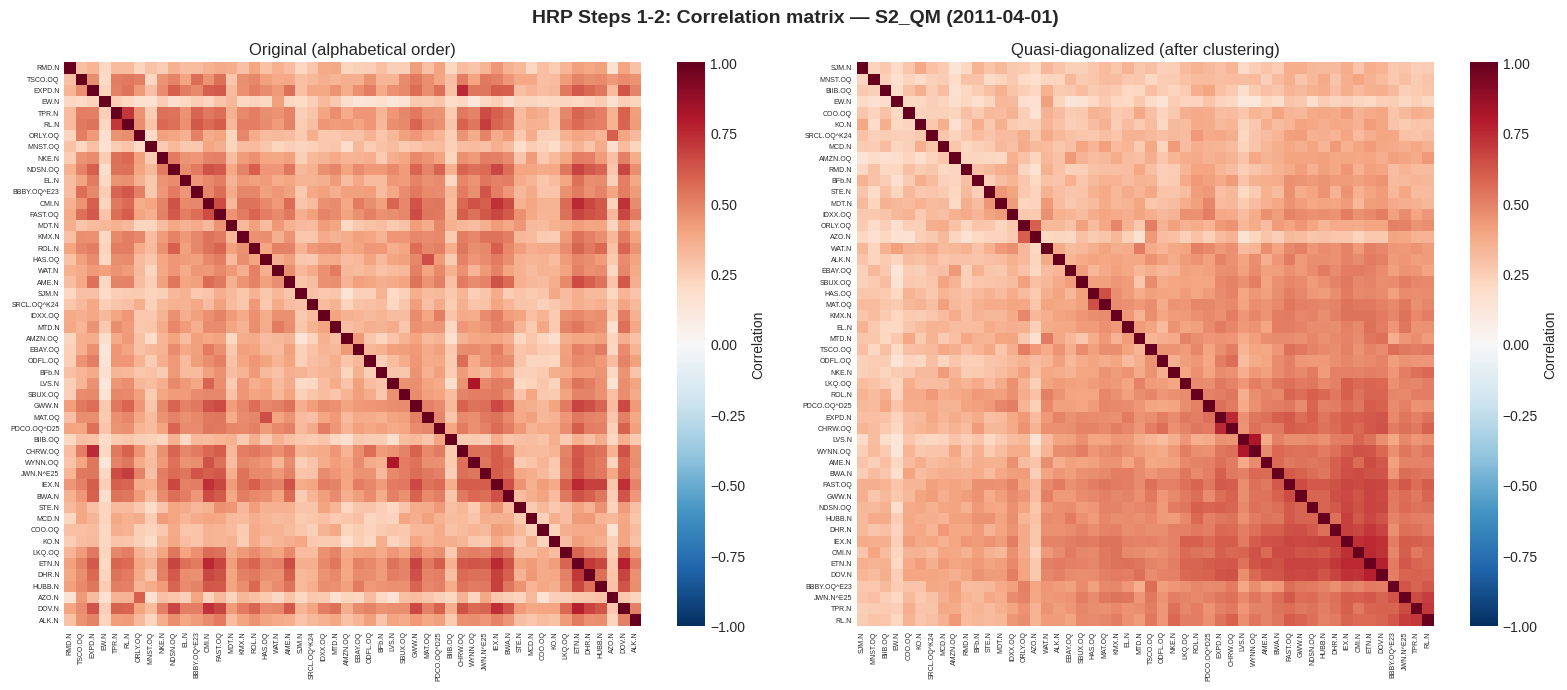

Variante: S2_QM | Fecha: 2011-04-01
Activos: 50 | Shrinkage: 0.0193 | Obs: 504

La quasi-diagonalización reordena los activos para que los más
correlacionados queden adyacentes (bloques rojos en la diagonal).
HRP explota esta estructura para asignar pesos sin invertir la matriz.


In [ ]:
# ============================================================
# CELDA 3.1 — HRP paso a paso: visualización pedagógica
# ============================================================
# >>> CAMBIAR AQUÍ para ver otra estrategia <
SHOW_VARIANT = 'S2_QM'    # Opciones: 'S1_Quality', 'S2_QM', 'S3_QVM'
# ============================================

# Seleccionar datos del primer rebalanceo para la variante elegida
show_date = rebal_schedule.iloc[0]['rebal_date']
show_rics = validated_universe[SHOW_VARIANT][show_date]
show_cov, show_shrink, show_nobs = get_cov_lw(log_returns, show_rics, show_date)

# --- Paso 1: Matriz de correlación original ---
show_std = np.sqrt(np.diag(show_cov))
show_corr = show_cov / np.outer(show_std, show_std)
show_corr = pd.DataFrame(show_corr, index=show_rics, columns=show_rics)
np.fill_diagonal(show_corr.values, 1.)

# --- Paso 2: Distancia de correlación ---
# d(i,j) = sqrt(0.5 * (1 - rho))  — López de Prado (2016)
show_dist = ((1 - show_corr) / 2.) ** 0.5

# --- Paso 3: Linkage ---
dist_condensed = squareform(show_dist.values, checks=False)
show_link = sch.linkage(dist_condensed, method=LINKAGE_METHOD)

# --- Paso 4: Quasi-diagonalización ---
def getQuasiDiag(link):
    link = link.astype(int)
    sortIx = pd.Series([link[-1, 0], link[-1, 1]])
    numItems = link[-1, 3]
    while sortIx.max() >= numItems:
        sortIx.index = range(0, sortIx.shape[0] * 2, 2)
        df0 = sortIx[sortIx >= numItems]
        i = df0.index
        j = df0.values - numItems
        sortIx[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sortIx = pd.concat([sortIx, df0])
        sortIx = sortIx.sort_index()
        sortIx.index = range(sortIx.shape[0])
    return sortIx.tolist()

sortIx = getQuasiDiag(show_link)
sorted_rics = [show_rics[i] for i in sortIx]
corr_sorted = show_corr.loc[sorted_rics, sorted_rics]

# --- GRÁFICOS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'HRP Steps 1-2: Correlation matrix — {SHOW_VARIANT} ({show_date.date()})',
             fontsize=14, fontweight='bold')

# Original
sns.heatmap(show_corr, ax=axes[0], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, cbar_kws={'label': 'Correlation'})
axes[0].set_title('Original (alphabetical order)', fontsize=12)
axes[0].tick_params(labelsize=5)

# Quasi-diagonalizada
sns.heatmap(corr_sorted, ax=axes[1], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, cbar_kws={'label': 'Correlation'})
axes[1].set_title('Quasi-diagonalized (after clustering)', fontsize=12)
axes[1].tick_params(labelsize=5)

plt.tight_layout()
plt.savefig(OUT_PATH + f'nb02_v3_corr_{SHOW_VARIANT}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Variante: {SHOW_VARIANT} | Fecha: {show_date.date()}")
print(f"Activos: {len(show_rics)} | Shrinkage: {show_shrink:.4f} | Obs: {show_nobs}")
print(f"\nLa quasi-diagonalización reordena los activos para que los más")
print(f"correlacionados queden adyacentes (bloques rojos en la diagonal).")
print(f"HRP explota esta estructura para asignar pesos sin invertir la matriz.")

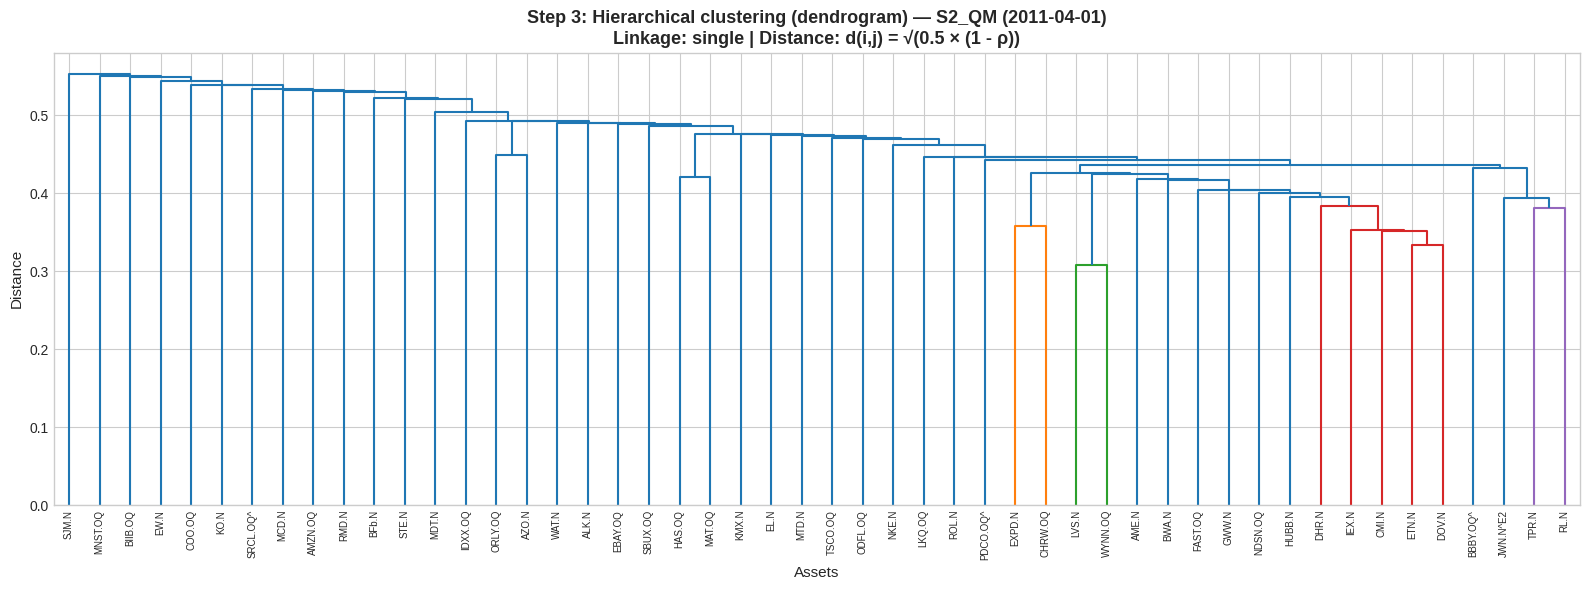

Clusters identificados (k=5):

  Cluster 1 (46 activos) — dominante: Consumer Discretionary
    RMD.N         Health Care                vol=25.4%
    TSCO.OQ       Consumer Discretionary     vol=30.6%
    EXPD.N        Industrials                vol=32.2%
    TPR.N         Consumer Discretionary     vol=36.6%
    RL.N          Consumer Discretionary     vol=36.4%
    ORLY.OQ       Consumer Discretionary     vol=26.0%
    NKE.N         Consumer Discretionary     vol=26.3%
    NDSN.OQ       Industrials                vol=36.7%
    EL.N          Consumer Staples           vol=33.7%
    BBBY.OQ^E23   Consumer Discretionary     vol=34.6%
    CMI.N         Industrials                vol=43.6%
    FAST.OQ       Industrials                vol=30.7%
    MDT.N         Health Care                vol=24.2%
    KMX.N         Consumer Discretionary     vol=43.6%
    ROL.N         Industrials                vol=25.7%
    HAS.OQ        Consumer Discretionary     vol=27.8%
    WAT.N         Health Car

In [ ]:
# ============================================================
# CELDA 3.2 — Dendrograma + clusters identificados
# ============================================================
# >>> CAMBIAR AQUÍ para ver otra estrategia <
SHOW_VARIANT = 'S2_QM'    # Opciones: 'S1_Quality', 'S2_QM', 'S3_QVM'
# ============================================

fig, ax = plt.subplots(figsize=(16, 6))

# Dendrograma con colores por cluster
sch.dendrogram(
    show_link,
    labels=[r[:8] for r in show_rics],  # Nombres cortos
    leaf_rotation=90,
    leaf_font_size=7,
    ax=ax,
    color_threshold=0.7 * max(show_link[:, 2])  # Umbral para colorear clusters
)

ax.set_title(f'Step 3: Hierarchical clustering (dendrogram) — {SHOW_VARIANT} ({show_date.date()})\n'
             f'Linkage: {LINKAGE_METHOD} | Distance: d(i,j) = √(0.5 × (1 - ρ))',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Distance', fontsize=11)
ax.set_xlabel('Assets', fontsize=11)

plt.tight_layout()
plt.savefig(OUT_PATH + f'nb02_v3_dendrogram_{SHOW_VARIANT}.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Análisis de clusters ---
# Cortar el dendrograma en clusters para ver la composición
from scipy.cluster.hierarchy import fcluster

n_clusters = 5
cluster_labels = fcluster(show_link, n_clusters, criterion='maxclust')

print(f"Clusters identificados (k={n_clusters}):")
print(f"{'='*60}")

for c in range(1, n_clusters + 1):
    members = [show_rics[i] for i in range(len(show_rics)) if cluster_labels[i] == c]
    sectors = [ric_sector.get(r, '?') for r in members]
    sector_counts = pd.Series(sectors).value_counts()
    dominant = sector_counts.index[0]

    print(f"\n  Cluster {c} ({len(members)} activos) — dominante: {dominant}")
    for ric in members:
        sect = ric_sector.get(ric, '?')
        vol = np.sqrt(show_cov.loc[ric, ric]) * np.sqrt(252)
        print(f"    {ric:12s}  {sect:25s}  vol={vol:.1%}")

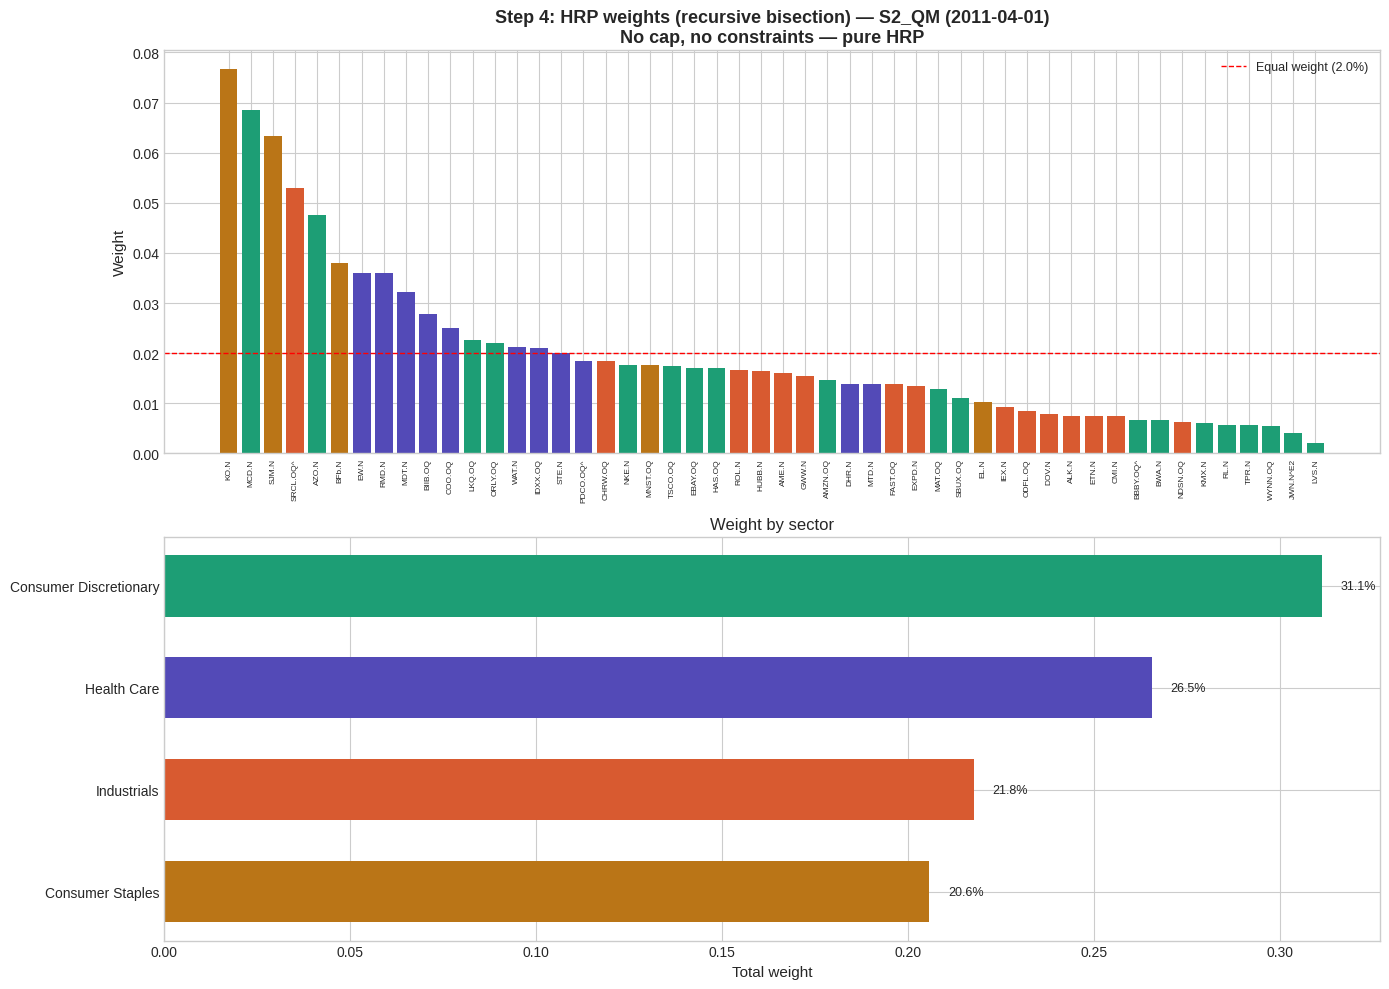


Pesos HRP — S2_QM (2011-04-01):
  Suma: 1.000000 | Todos >0: True
  Max:  7.7% (KO.N)
  Min:  0.2% (LVS.N)
  Mean: 2.0% | Std: 1.7%
  Top 5 suman: 30.9%

  Top 5:
    KO.N         7.7%  vol=16.5%  Consumer Staples
    MCD.N        6.9%  vol=17.1%  Consumer Discretionary
    SJM.N        6.3%  vol=19.0%  Consumer Staples
    SRCL.OQ^K24  5.3%  vol=21.5%  Industrials
    AZO.N        4.8%  vol=20.8%  Consumer Discretionary

  Bottom 5:
    LVS.N        0.2%  vol=72.7%  Consumer Discretionary
    JWN.N^E25    0.4%  vol=44.1%  Consumer Discretionary
    WYNN.OQ      0.5%  vol=56.7%  Consumer Discretionary
    TPR.N        0.6%  vol=36.6%  Consumer Discretionary
    RL.N         0.6%  vol=36.4%  Consumer Discretionary


In [ ]:
# ============================================================
# CELDA 3.3 — Pesos HRP: bisección recursiva paso a paso
# ============================================================
# >>> CAMBIAR AQUÍ para ver otra estrategia <
SHOW_VARIANT = 'S2_QM'    # Opciones: 'S1_Quality', 'S2_QM', 'S3_QVM'
# ============================================

# --- Funciones HRP (definitivas para v3) ---
def correlDist(corr):
    """Distancia: d(i,j) = sqrt(0.5 * (1 - rho)). Ref: LdP (2016)"""
    return ((1 - corr) / 2.) ** 0.5

def getIVP(cov):
    """Inverse-Variance Portfolio. Ref: LdP (2016), Appendix A.2"""
    ivp = 1. / np.diag(cov)
    ivp /= ivp.sum()
    return ivp

def getClusterVar(cov, cItems):
    """Varianza del cluster con pesos IVP. Ref: LdP (2016), Step 3.b"""
    cov_ = cov.loc[cItems, cItems]
    w_ = getIVP(cov_).reshape(-1, 1)
    return np.dot(np.dot(w_.T, cov_), w_)[0, 0]

def getRecBipart(cov, sortIx):
    """Recursive bisection. Ref: LdP (2016), Code Snippet 2"""
    w = pd.Series(1., index=sortIx)
    cItems = [sortIx]
    while len(cItems) > 0:
        cItems = [i[j:k] for i in cItems
                  for j, k in ((0, len(i)//2), (len(i)//2, len(i)))
                  if len(i) > 1]
        for i in range(0, len(cItems), 2):
            cItems0, cItems1 = cItems[i], cItems[i+1]
            cVar0 = getClusterVar(cov, cItems0)
            cVar1 = getClusterVar(cov, cItems1)
            alpha = 1 - cVar0 / (cVar0 + cVar1)
            w[cItems0] *= alpha
            w[cItems1] *= (1 - alpha)
    return w

def hrp_weights(cov, linkage_method='single'):
    """Pipeline HRP completo. Ref: LdP (2016), getHRP Appendix A.3"""
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    corr = pd.DataFrame(corr, index=cov.index, columns=cov.columns)
    np.fill_diagonal(corr.values, 1.)
    dist = correlDist(corr)
    link = sch.linkage(squareform(dist.values, checks=False), method=linkage_method)
    sortIx = getQuasiDiag(link)
    sortIx = corr.index[sortIx].tolist()
    return getRecBipart(cov, sortIx).sort_index()

# --- Calcular pesos ---
w_show = hrp_weights(show_cov, LINKAGE_METHOD)

# --- Gráfico: pesos ordenados por magnitud ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: Pesos por magnitud
w_sorted = w_show.sort_values(ascending=False)
colors_bar = []
for ric in w_sorted.index:
    sect = ric_sector.get(ric, '?')
    color_map = {
        'Health Care': '#534AB7', 'Consumer Discretionary': '#1D9E75',
        'Industrials': '#D85A30', 'Consumer Staples': '#BA7517',
        'Information Technology': '#185FA5', 'Financials': '#639922',
        'Communication Services': '#854F0B', 'Energy': '#E24B4A',
        'Materials': '#888780', 'Real Estate': '#D4537E'
    }
    colors_bar.append(color_map.get(sect, '#888780'))

axes[0].bar(range(len(w_sorted)), w_sorted.values, color=colors_bar, width=0.8)
axes[0].set_xticks(range(len(w_sorted)))
axes[0].set_xticklabels([r[:8] for r in w_sorted.index], rotation=90, fontsize=6)
axes[0].set_ylabel('Weight', fontsize=11)
axes[0].set_title(f'Step 4: HRP weights (recursive bisection) — {SHOW_VARIANT} ({show_date.date()})\n'
                  f'No cap, no constraints — pure HRP', fontsize=13, fontweight='bold')
axes[0].axhline(1/TOP_N, color='red', ls='--', lw=1, label=f'Equal weight ({1/TOP_N:.1%})')
axes[0].legend(fontsize=9)

# Panel 2: Pesos por sector (agregados)
sector_w = {}
for ric, w in w_show.items():
    sect = ric_sector.get(ric, '?')
    sector_w[sect] = sector_w.get(sect, 0) + w

sector_w = pd.Series(sector_w).sort_values(ascending=True)
sect_colors = [color_map.get(s, '#888780') for s in sector_w.index]

axes[1].barh(sector_w.index, sector_w.values, color=sect_colors, height=0.6)
axes[1].set_xlabel('Total weight', fontsize=11)
axes[1].set_title('Weight by sector', fontsize=12)

for i, (sect, val) in enumerate(sector_w.items()):
    axes[1].text(val + 0.005, i, f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_PATH + f'nb02_v3_weights_{SHOW_VARIANT}.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Stats ---
print(f"\nPesos HRP — {SHOW_VARIANT} ({show_date.date()}):")
print(f"  Suma: {w_show.sum():.6f} | Todos >0: {(w_show>0).all()}")
print(f"  Max:  {w_show.max():.1%} ({w_show.idxmax()})")
print(f"  Min:  {w_show.min():.1%} ({w_show.idxmin()})")
print(f"  Mean: {w_show.mean():.1%} | Std: {w_show.std():.1%}")
print(f"  Top 5 suman: {w_show.nlargest(5).sum():.1%}")
print(f"\n  Top 5:")
for ric, w in w_show.nlargest(5).items():
    sect = ric_sector.get(ric, '?')
    vol = np.sqrt(show_cov.loc[ric, ric]) * np.sqrt(252)
    print(f"    {ric:12s} {w:.1%}  vol={vol:.1%}  {sect}")
print(f"\n  Bottom 5:")
for ric, w in w_show.nsmallest(5).items():
    sect = ric_sector.get(ric, '?')
    vol = np.sqrt(show_cov.loc[ric, ric]) * np.sqrt(252)
    print(f"    {ric:12s} {w:.1%}  vol={vol:.1%}  {sect}")

In [ ]:
# ============================================================
# CELDA 4.1 — Pipeline de pesos finales (HRP puro v3)
# ============================================================
# >>> CAMBIAR AQUÍ para ver otra estrategia <
SHOW_VARIANT = 'S2_QM'    # Opciones: 'S1_Quality', 'S2_QM', 'S3_QVM'
# ============================================

def get_final_weights(cov, linkage_method=LINKAGE_METHOD):
    """
    Pipeline v3: HRP puro, sin cap, sin threshold.
    El modelo asigna pesos libremente basándose únicamente
    en la estructura jerárquica de correlaciones.

    Ref: López de Prado (2016)
    """
    w = hrp_weights(cov, linkage_method)

    assert abs(w.sum() - 1.0) < 1e-6, f"Suma = {w.sum()}"
    assert (w >= 0).all(), "Pesos negativos"
    return w


# --- Test ---
w_pipeline = get_final_weights(show_cov)

print(f"Test pipeline HRP puro — {SHOW_VARIANT} ({show_date.date()}):")
print(f"  Suma:  {w_pipeline.sum():.6f}")
print(f"  Count: {len(w_pipeline)}")
print(f"  Max:   {w_pipeline.max():.1%} ({w_pipeline.idxmax()})")
print(f"  Min:   {w_pipeline.min():.1%} ({w_pipeline.idxmin()})")
print(f"  >5%:   {(w_pipeline > 0.05).sum()} RICs")
print(f"  >10%:  {(w_pipeline > 0.10).sum()} RICs")

Test pipeline HRP puro — S2_QM (2011-04-01):
  Suma:  1.000000
  Count: 50
  Max:   7.7% (KO.N)
  Min:   0.2% (LVS.N)
  >5%:   4 RICs
  >10%:  0 RICs


In [ ]:
# ============================================================
# CELDA 5.1 — Motor de backtest v3
# ============================================================

def compute_drifted_weights(w_prev, simple_returns, start_date, end_date):
    """Pesos drifted por market returns entre rebalanceos."""
    rics = w_prev.index.tolist()
    mask = (simple_returns.index > start_date) & (simple_returns.index < end_date)
    period_ret = simple_returns.loc[mask, rics]
    if len(period_ret) == 0:
        return w_prev.copy()
    cum = (1 + period_ret.fillna(0.)).prod()
    w_d = w_prev * cum
    return w_d / w_d.sum()


def align_weights(w_drifted, new_rics):
    """Alinear pesos drifted al nuevo universo."""
    w_aligned = w_drifted.reindex(new_rics, fill_value=0.)
    total = w_aligned.sum()
    return w_aligned / total if total > 0 else pd.Series(1./len(new_rics), index=new_rics)


def handle_delisting_intraperiod(w_current, active_rics, prices,
                                 current_date, next_rebal_date,
                                 simple_returns, variant, fy):
    """
    Detecta delistings intra-trimestre y reemplaza inmediatamente.

    Retorna:
        daily_nav_updates: list of (date, nav_multiplier)
        w_updated: pesos actualizados post-reemplazo
        delist_events: list of dicts con eventos de delisting
    """
    delist_events = []
    w = w_current.copy()
    rics = list(active_rics)

    period_prices = prices.loc[current_date:next_rebal_date, rics]

    for ric in rics:
        if ric not in period_prices.columns:
            continue
        series = period_prices[ric]

        # Buscar gap > MAX_GAP_DAYS
        gap_count = 0
        delist_date = None
        for date, val in series.items():
            if date <= current_date:
                continue
            if pd.isna(val):
                gap_count += 1
                if gap_count > MAX_GAP_DAYS:
                    delist_date = series.index[series.index <= date][-(gap_count)]
                    break
            else:
                gap_count = 0

        if delist_date is not None:
            # Encontrar reemplazo
            replacement = find_replacement(variant, fy, rics, delist_date)

            if replacement:
                # Transferir peso del delisted al reemplazo
                old_weight = w.get(ric, 0)
                w = w.drop(ric, errors='ignore')
                w[replacement] = old_weight
                rics.remove(ric)
                rics.append(replacement)

                delist_events.append({
                    'date': delist_date,
                    'delisted': ric,
                    'replacement': replacement,
                    'weight_transferred': old_weight
                })

    return w, rics, delist_events


def run_backtest_v3(variant):
    """
    Motor de backtest v3:
    - HRP puro (sin cap, sin threshold)
    - Detección y reemplazo de delisted intra-trimestre
    - Siempre 50 posiciones
    """
    weights_history = {}
    nav_dict = {}
    turnover_history = {}
    cost_history = {}
    delist_log = []

    # Para descomposición de turnover
    turnover_universe = {}   # Por cambio de universo
    turnover_weights = {}    # Por rebalanceo de pesos

    nav = 100.0
    w_prev = None
    prev_rebal_date = None

    schedule = rebal_schedule[
        rebal_schedule['rebal_date'] <= pd.Timestamp(BT_END)].copy()

    for idx in range(len(schedule)):
        row = schedule.iloc[idx]
        rebal_date = row['rebal_date']
        fy = row['fiscal_year']
        is_annual = row['rebal_type'] == 'ANNUAL'
        rics = validated_universe[variant][rebal_date]

        # 1. Covarianza
        cov, _, _ = get_cov_lw(log_returns, rics, rebal_date)

        # 2. Pesos drifted
        if w_prev is not None:
            w_drifted = compute_drifted_weights(
                w_prev, simple_returns, prev_rebal_date, rebal_date)
            w_drifted_aligned = align_weights(w_drifted, rics)
        else:
            w_drifted_aligned = None

        # 3. HRP puro
        w_final = get_final_weights(cov)

        weights_history[rebal_date] = w_final

        # 4. Turnover y costos
        if w_drifted_aligned is not None:
            all_r = w_final.index.union(w_drifted_aligned.index)
            wf = w_final.reindex(all_r, fill_value=0.)
            wd = w_drifted_aligned.reindex(all_r, fill_value=0.)
            diff = (wf - wd).abs()

            turnover = diff.sum() / 2
            cost = turnover * COST_BP

            # Descomposición: turnover por cambio de universo vs pesos
            if is_annual:
                new_rics = set(rics) - set(w_prev.index)
                old_rics = set(w_prev.index) - set(rics)
                # Turnover de universo = peso de los que entran/salen
                to_univ = sum(wd.get(r, 0) for r in old_rics) + sum(wf.get(r, 0) for r in new_rics)
                to_weights = turnover * 2 - to_univ  # Resto es por rebalanceo
                turnover_universe[rebal_date] = to_univ / 2
                turnover_weights[rebal_date] = max(0, turnover - to_univ / 2)
            else:
                turnover_universe[rebal_date] = 0.
                turnover_weights[rebal_date] = turnover
        else:
            turnover = 1.0
            cost = 1.0 * COST_BP
            turnover_universe[rebal_date] = 1.0
            turnover_weights[rebal_date] = 0.

        turnover_history[rebal_date] = turnover
        cost_history[rebal_date] = cost

        # 5. NAV: costo el día del rebalanceo
        nav *= (1 - cost)
        nav_dict[rebal_date] = nav

        # 6. Detectar delistings y NAV diario
        next_date = (schedule.iloc[idx+1]['rebal_date'] if idx < len(schedule)-1
                     else prices.index[prices.index <= pd.Timestamp(BT_END)][-1])

        # Verificar delistings
        w_active, active_rics, events = handle_delisting_intraperiod(
            w_final, rics, prices, rebal_date, next_date,
            simple_returns, variant, fy)
        delist_log.extend(events)

        if events:
            # Aplicar costo del reemplazo (solo peso transferido × 10bp)
            for ev in events:
                nav *= (1 - ev['weight_transferred'] * COST_BP)

        # NAV diario
        daily_mask = (simple_returns.index > rebal_date) & (simple_returns.index <= next_date)

        for day in simple_returns.index[daily_mask]:
            day_ret = simple_returns.loc[day, w_active.index].fillna(0.)
            r_p = (w_active * day_ret).sum()
            nav *= (1 + r_p)
            nav_dict[day] = nav

        w_prev = w_active
        prev_rebal_date = rebal_date

    return {
        'nav': pd.Series(nav_dict).sort_index(),
        'weights_history': weights_history,
        'turnover_history': pd.Series(turnover_history),
        'cost_history': pd.Series(cost_history),
        'turnover_universe': pd.Series(turnover_universe),
        'turnover_weights': pd.Series(turnover_weights),
        'delist_log': delist_log
    }


# --- Ejecutar ---
print("Ejecutando backtests v3 (HRP puro + delisting detection)...")
print("=" * 60)

all_results = {}
for variant in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    t0 = time.time()
    print(f"\n  {variant}...", end=" ", flush=True)
    all_results[variant] = run_backtest_v3(variant)

    res = all_results[variant]
    n_delist = len(res['delist_log'])
    print(f"OK ({time.time()-t0:.1f}s)")
    print(f"    NAV: {res['nav'].iloc[-1]:.2f} | "
          f"Turnover: {res['turnover_history'].mean():.1%} | "
          f"Costos: {res['cost_history'].sum():.2%} | "
          f"Delistings: {n_delist}")

    if n_delist > 0:
        for ev in res['delist_log']:
            print(f"      {ev['date'].date()}: {ev['delisted']} → {ev['replacement']} "
                  f"(w={ev['weight_transferred']:.1%})")

# --- Descomposición de turnover ---
print(f"\n{'='*60}")
print("Descomposición de turnover (promedio anual):")
for variant in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    res = all_results[variant]
    to_u = res['turnover_universe'].groupby(res['turnover_universe'].index.year).sum().mean()
    to_w = res['turnover_weights'].groupby(res['turnover_weights'].index.year).sum().mean()
    to_total = res['turnover_history'].groupby(res['turnover_history'].index.year).sum().mean()
    print(f"  {variant:15s}: total={to_total:.1%} "
          f"(universo={to_u:.1%} + pesos={to_w:.1%})")

Ejecutando backtests v3 (HRP puro + delisting detection)...

  S1_Quality... OK (17.7s)
    NAV: 743.17 | Turnover: 17.3% | Costos: 1.02% | Delistings: 0

  S2_QM... OK (14.8s)
    NAV: 734.68 | Turnover: 27.2% | Costos: 1.61% | Delistings: 0

  S3_QVM... OK (14.8s)
    NAV: 547.94 | Turnover: 26.9% | Costos: 1.59% | Delistings: 0

Descomposición de turnover (promedio anual):
  S1_Quality     : total=68.0% (universo=20.7% + pesos=47.4%)
  S2_QM          : total=107.2% (universo=40.7% + pesos=66.5%)
  S3_QVM         : total=105.8% (universo=40.9% + pesos=64.9%)


In [ ]:
# ============================================================
# CELDA 6.1 — Benchmarks: S&P 500 + Equal-Weight trimestral
# ============================================================
import yfinance as yf

# --- B1: S&P 500 ---
print("1. S&P 500...")
gspc = yf.download(BENCH_TICKER, start='2011-01-01', end='2026-01-01',
                   auto_adjust=True, progress=False)
gspc_close = gspc['Close'].squeeze()
gspc_close.index = gspc_close.index.tz_localize(None)

start_idx = gspc_close.index[gspc_close.index >= pd.Timestamp(BT_START)][0]
gspc_nav = (gspc_close / gspc_close.loc[start_idx]) * 100
gspc_nav = gspc_nav.loc[BT_START:]
print(f"   NAV final: {gspc_nav.iloc[-1]:.2f}")

# --- B2: Equal-Weight con rebalanceo trimestral (comparación justa) ---
print("\n2. Equal-Weight trimestral (por variante)...")

def run_equal_weight_quarterly(variant):
    """
    EW benchmark con rebalanceo trimestral: misma frecuencia que HRP.
    Cada trimestre se vuelve a igualar pesos a 1/N.
    """
    nav_dict = {}
    nav = 100.0

    schedule = rebal_schedule[
        rebal_schedule['rebal_date'] <= pd.Timestamp(BT_END)].copy()

    w_prev_rics = None

    for idx in range(len(schedule)):
        row = schedule.iloc[idx]
        rebal_date = row['rebal_date']
        rics = validated_universe[variant][rebal_date]

        w_ew = pd.Series(1. / len(rics), index=rics)

        # Costo: turnover de volver a 1/N + cambio de universo
        if w_prev_rics is not None:
            # Simular drift de pesos previos
            w_prev_ew = pd.Series(1. / len(w_prev_rics), index=w_prev_rics)
            w_drifted = compute_drifted_weights(
                w_prev_ew, simple_returns, prev_rd, rebal_date)
            w_drifted_aligned = align_weights(w_drifted, rics)

            all_r = w_ew.index.union(w_drifted_aligned.index)
            diff = (w_ew.reindex(all_r, fill_value=0.) -
                    w_drifted_aligned.reindex(all_r, fill_value=0.)).abs()
            turnover = diff.sum() / 2
            cost = turnover * COST_BP
        else:
            cost = 1.0 * COST_BP

        nav *= (1 - cost)
        nav_dict[rebal_date] = nav

        # NAV diario
        next_date = (schedule.iloc[idx+1]['rebal_date'] if idx < len(schedule)-1
                     else prices.index[prices.index <= pd.Timestamp(BT_END)][-1])

        for day in simple_returns.index[(simple_returns.index > rebal_date) &
                                         (simple_returns.index <= next_date)]:
            r = (w_ew * simple_returns.loc[day, rics].fillna(0.)).sum()
            nav *= (1 + r)
            nav_dict[day] = nav

        w_prev_rics = rics
        prev_rd = rebal_date

    return pd.Series(nav_dict).sort_index()


ew_results = {}
for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    ew_results[v] = run_equal_weight_quarterly(v)
    print(f"   EW {v}: {ew_results[v].iloc[-1]:.2f}")

# --- Risk-free ---
print("\n3. Tasa libre de riesgo...")
irx = yf.download(RF_TICKER, start='2011-01-01', end='2026-01-01',
                   auto_adjust=True, progress=False)
irx_close = irx['Close'].squeeze()
irx_close.index = irx_close.index.tz_localize(None)
rf_annual = irx_close.loc[BT_START:BT_END].mean() / 100
print(f"   Rf: {rf_annual:.2%}")

# --- Resumen ---
print(f"\n{'='*60}")
print("NAV final (base 100):")
print(f"  {'Variante':15s}  {'HRP':>8s}  {'EW (trim)':>10s}  {'Δ':>8s}")
print(f"  {'-'*45}")
for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    nav_hrp = all_results[v]['nav'].iloc[-1]
    nav_ew = ew_results[v].iloc[-1]
    delta = nav_hrp - nav_ew
    print(f"  {v:15s}  {nav_hrp:>8.1f}  {nav_ew:>10.1f}  {delta:>+8.1f}")
print(f"  {'B1 S&P 500':15s}  {gspc_nav.iloc[-1]:>8.1f}")

1. S&P 500...
   NAV final: 513.77

2. Equal-Weight trimestral (por variante)...
   EW S1_Quality: 879.60
   EW S2_QM: 927.94
   EW S3_QVM: 691.88

3. Tasa libre de riesgo...
   Rf: 1.48%

NAV final (base 100):
  Variante              HRP   EW (trim)         Δ
  ---------------------------------------------
  S1_Quality          743.2       879.6    -136.4
  S2_QM               734.7       927.9    -193.3
  S3_QVM              547.9       691.9    -143.9
  B1 S&P 500          513.8


In [ ]:
# ============================================================
# CELDA 7.1 — Métricas completas + retorno bruto vs neto
# ============================================================

def compute_metrics(nav_series, rf_annual, name=''):
    daily_ret = nav_series.pct_change().dropna()
    n_days = len(daily_ret)
    n_years = n_days / 252
    total_return = nav_series.iloc[-1] / nav_series.iloc[0]
    cagr = total_return ** (1 / n_years) - 1
    vol = daily_ret.std() * np.sqrt(252)
    sharpe = (cagr - rf_annual) / vol
    sortino = (cagr - rf_annual) / (daily_ret[daily_ret < 0].std() * np.sqrt(252))
    running_max = nav_series.cummax()
    max_dd = ((nav_series - running_max) / running_max).min()
    calmar = cagr / abs(max_dd)
    return {
        'Strategy': name, 'CAGR': cagr, 'Vol': vol,
        'Sharpe': sharpe, 'Sortino': sortino,
        'Max DD': max_dd, 'Calmar': calmar, 'NAV': nav_series.iloc[-1]
    }

# --- Tabla principal ---
metrics = []
for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    m_hrp = compute_metrics(all_results[v]['nav'], rf_annual, f"{v}_HRP")
    m_hrp['Total Cost'] = all_results[v]['cost_history'].sum()
    m_hrp['Avg Turnover'] = all_results[v]['turnover_history'].mean()
    m_hrp['TO Universe'] = all_results[v]['turnover_universe'].groupby(
        all_results[v]['turnover_universe'].index.year).sum().mean()
    m_hrp['TO Weights'] = all_results[v]['turnover_weights'].groupby(
        all_results[v]['turnover_weights'].index.year).sum().mean()
    metrics.append(m_hrp)

    m_ew = compute_metrics(ew_results[v], rf_annual, f"{v}_EW")
    metrics.append(m_ew)

m_sp = compute_metrics(gspc_nav, rf_annual, 'B1_SP500')
metrics.append(m_sp)

df_m = pd.DataFrame(metrics).set_index('Strategy')

# --- Display: métricas de riesgo-retorno ---
print("=" * 90)
print("MÉTRICAS DE PERFORMANCE — HRP puro vs EW trimestral vs S&P 500")
print(f"Período: {BT_START} → {BT_END} | Rf = {rf_annual:.2%} | Costos = {COST_BP*10000:.0f}bp")
print("=" * 90)

cols_show = ['CAGR', 'Vol', 'Sharpe', 'Sortino', 'Max DD', 'Calmar', 'NAV']
fmt = df_m[cols_show].copy()
for c in ['CAGR', 'Vol', 'Max DD']:
    fmt[c] = fmt[c].apply(lambda x: f"{x:.2%}")
for c in ['Sharpe', 'Sortino', 'Calmar']:
    fmt[c] = fmt[c].apply(lambda x: f"{x:.2f}")
fmt['NAV'] = fmt['NAV'].apply(lambda x: f"{x:.1f}")
print(fmt.to_string())

# --- Display: retorno bruto vs neto ---
print(f"\n{'='*90}")
print("RETORNO BRUTO vs NETO (post-costos)")
print(f"{'='*90}")
print(f"{'Strategy':20s} {'CAGR (neto)':>12s} {'Total Cost':>12s} {'CAGR bruto*':>12s} {'Δ costo':>10s}")
print("-" * 70)

for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    # CAGR neto (ya lo tenemos, incluye costos)
    cagr_neto = df_m.loc[f"{v}_HRP", 'CAGR']
    total_cost = all_results[v]['cost_history'].sum()

    # CAGR bruto aproximado: deshacer costos
    nav_final = all_results[v]['nav'].iloc[-1]
    nav_bruto_approx = nav_final / (1 - total_cost)  # Aproximación
    n_years = len(all_results[v]['nav'].pct_change().dropna()) / 252
    cagr_bruto = (nav_bruto_approx / 100) ** (1/n_years) - 1

    delta = cagr_bruto - cagr_neto

    print(f"  {v+'_HRP':18s} {cagr_neto:>11.2%} {total_cost:>11.2%} {cagr_bruto:>11.2%} {delta:>9.2%}")

    # EW
    cagr_ew = df_m.loc[f"{v}_EW", 'CAGR']
    print(f"  {v+'_EW':18s} {cagr_ew:>11.2%} {'—':>11s} {'—':>11s} {'—':>9s}")

print(f"\n  * CAGR bruto = aproximación revirtiendo costos acumulados")

# --- Contribución HRP vs EW ---
print(f"\n{'='*90}")
print("CONTRIBUCIÓN DE HRP (vs Equal-Weight trimestral)")
print(f"{'='*90}")
print(f"{'Variante':15s} {'Sharpe HRP':>11s} {'Sharpe EW':>10s} {'Δ Sharpe':>10s} "
      f"{'Vol HRP':>9s} {'Vol EW':>8s} {'Δ Vol':>8s} "
      f"{'MDD HRP':>9s} {'MDD EW':>8s}")
print("-" * 95)

for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    h = df_m.loc[f"{v}_HRP"]
    e = df_m.loc[f"{v}_EW"]
    print(f"  {v:13s} {h['Sharpe']:>10.2f} {e['Sharpe']:>10.2f} {h['Sharpe']-e['Sharpe']:>+10.2f} "
          f"{h['Vol']:>8.2%} {e['Vol']:>8.2%} {h['Vol']-e['Vol']:>+8.2%} "
          f"{h['Max DD']:>8.2%} {e['Max DD']:>8.2%}")

MÉTRICAS DE PERFORMANCE — HRP puro vs EW trimestral vs S&P 500
Período: 2011-04-01 → 2025-12-31 | Rf = 1.48% | Costos = 10bp
                  CAGR     Vol Sharpe Sortino   Max DD Calmar    NAV
Strategy                                                            
S1_Quality_HRP  14.61%  16.88%   0.78    1.01  -31.14%   0.47  743.2
S1_Quality_EW   15.93%  19.16%   0.75    0.98  -31.34%   0.51  879.6
S2_QM_HRP       14.52%  18.41%   0.71    0.92  -32.52%   0.45  734.7
S2_QM_EW        16.35%  21.08%   0.71    0.92  -33.85%   0.48  927.9
S3_QVM_HRP      12.26%  17.53%   0.61    0.75  -38.90%   0.32  547.9
S3_QVM_EW       14.05%  19.90%   0.63    0.80  -39.20%   0.36  691.9
B1_SP500        11.76%  17.35%   0.59    0.73  -33.92%   0.35  513.8

RETORNO BRUTO vs NETO (post-costos)
Strategy              CAGR (neto)   Total Cost  CAGR bruto*    Δ costo
----------------------------------------------------------------------
  S1_Quality_HRP          14.61%       1.02%      14.68%     0.07%
  S1_Qua

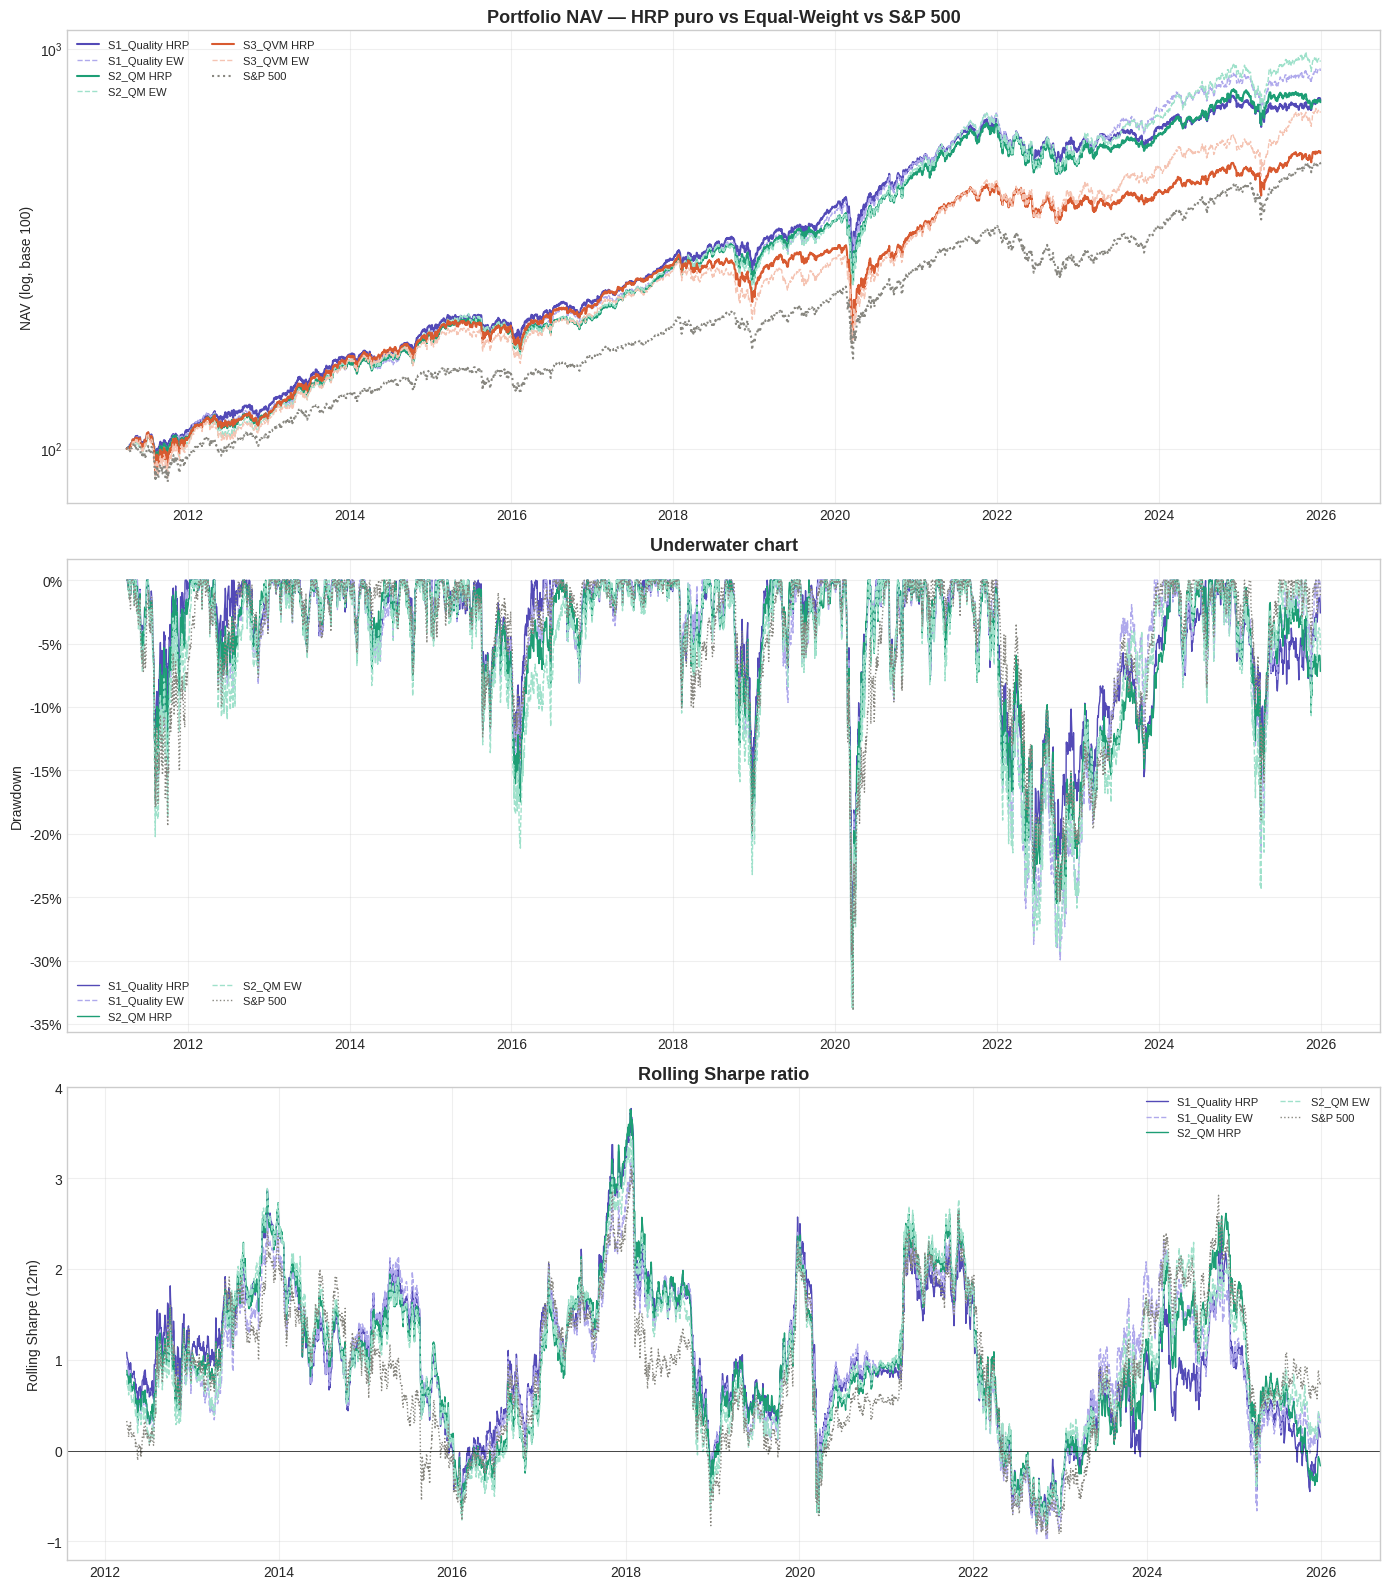

Guardado: nb02_v3_performance.png


In [ ]:
# ============================================================
# CELDA 7.2 — Gráficos de performance
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

colors_hrp = {'S1_Quality': '#534AB7', 'S2_QM': '#1D9E75', 'S3_QVM': '#D85A30'}
colors_ew  = {'S1_Quality': '#AFA9EC', 'S2_QM': '#9FE1CB', 'S3_QVM': '#F5C4B3'}

# --- 1. NAV ---
ax = axes[0]
for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    ax.plot(all_results[v]['nav'], color=colors_hrp[v], lw=1.5, label=f'{v} HRP')
    ax.plot(ew_results[v], color=colors_ew[v], lw=1, ls='--', label=f'{v} EW')
ax.plot(gspc_nav, color='#888780', lw=1.5, ls=':', label='S&P 500')
ax.set_yscale('log')
ax.set_ylabel('NAV (log, base 100)')
ax.set_title('Portfolio NAV — HRP puro vs Equal-Weight vs S&P 500', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# --- 2. Drawdown ---
ax = axes[1]
for v in ['S1_Quality', 'S2_QM']:
    for label, nav, color, ls in [(f'{v} HRP', all_results[v]['nav'], colors_hrp[v], '-'),
                                    (f'{v} EW', ew_results[v], colors_ew[v], '--')]:
        dd = (nav - nav.cummax()) / nav.cummax()
        ax.plot(dd, color=color, lw=1, ls=ls, label=label)
dd_sp = (gspc_nav - gspc_nav.cummax()) / gspc_nav.cummax()
ax.plot(dd_sp, color='#888780', lw=1, ls=':', label='S&P 500')
ax.set_ylabel('Drawdown')
ax.set_title('Underwater chart', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# --- 3. Rolling Sharpe 12m ---
ax = axes[2]
roll = 252
for v in ['S1_Quality', 'S2_QM']:
    for label, nav, color, ls in [(f'{v} HRP', all_results[v]['nav'], colors_hrp[v], '-'),
                                    (f'{v} EW', ew_results[v], colors_ew[v], '--')]:
        ret = nav.pct_change().dropna()
        rs = (ret.rolling(roll).mean() * 252 - rf_annual) / (ret.rolling(roll).std() * np.sqrt(252))
        ax.plot(rs, color=color, lw=1, ls=ls, label=label)

ret_sp = gspc_nav.pct_change().dropna()
rs_sp = (ret_sp.rolling(roll).mean() * 252 - rf_annual) / (ret_sp.rolling(roll).std() * np.sqrt(252))
ax.plot(rs_sp, color='#888780', lw=1, ls=':', label='S&P 500')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Rolling Sharpe (12m)')
ax.set_title('Rolling Sharpe ratio', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PATH + 'nb02_v3_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: nb02_v3_performance.png")

In [ ]:
# ============================================================
# CELDA 7.3 — Subperíodos + test estadístico de Sharpe
# ============================================================

# --- 1. Subperíodos ---
print("ANÁLISIS POR SUBPERÍODO")
print("=" * 95)

subperiods = [
    ('2011-2014', '2011-04-01', '2014-12-31'),
    ('2015-2019', '2015-01-01', '2019-12-31'),
    ('2020-2025', '2020-01-01', '2025-12-31')
]

strategies = {
    'S1_HRP': all_results['S1_Quality']['nav'],
    'S1_EW':  ew_results['S1_Quality'],
    'S2_HRP': all_results['S2_QM']['nav'],
    'S2_EW':  ew_results['S2_QM'],
    'SP500':  gspc_nav
}

for metric_name in ['CAGR', 'Vol', 'Sharpe', 'Max DD']:
    print(f"\n  {metric_name}:")
    print(f"  {'Period':>10s}", end="")
    for name in strategies:
        print(f"  {name:>10s}", end="")
    print()
    print(f"  {'-'*65}")

    for label, start, end in subperiods:
        print(f"  {label:>10s}", end="")
        for name, nav in strategies.items():
            sub = nav.loc[start:end]
            if len(sub) < 50:
                print(f"  {'—':>10s}", end="")
                continue
            m = compute_metrics(sub, rf_annual)
            if metric_name in ['CAGR', 'Vol', 'Max DD']:
                print(f"  {m[metric_name]:>9.2%}", end="")
            else:
                print(f"  {m[metric_name]:>9.2f}", end="")
        print()

# --- 2. Test estadístico: diferencia de Sharpe ---
print(f"\n{'='*95}")
print("TEST ESTADÍSTICO — Diferencia de Sharpe (Jobson-Korkie, 1981)")
print("H0: Sharpe(estrategia) = Sharpe(S&P 500)")
print("=" * 95)

def sharpe_difference_test(nav1, nav2, rf_annual):
    """
    Test de Jobson-Korkie (1981) para diferencia de Sharpe ratios.
    Corregido por Memmel (2003).

    H0: SR1 = SR2
    Returns: z-stat, p-value (two-sided)
    """
    r1 = nav1.pct_change().dropna()
    r2 = nav2.pct_change().dropna()

    # Alinear fechas
    common = r1.index.intersection(r2.index)
    r1 = r1.loc[common]
    r2 = r2.loc[common]
    n = len(r1)

    mu1, mu2 = r1.mean(), r2.mean()
    s1, s2 = r1.std(), r2.std()
    sr1 = (mu1 - rf_annual/252) / s1
    sr2 = (mu2 - rf_annual/252) / s2

    # Correlación entre los dos retornos
    rho = r1.corr(r2)

    # Varianza asintótica (Memmel 2003)
    theta = (1/n) * (2 * (1 - rho) + 0.5 * (sr1**2 + sr2**2 - sr1 * sr2 * (1 + rho**2)))

    if theta <= 0:
        return 0., 1.

    z = (sr1 - sr2) / np.sqrt(theta)

    from scipy.stats import norm
    p_value = 2 * (1 - norm.cdf(abs(z)))

    # Anualizar Sharpe para display
    sr1_ann = sr1 * np.sqrt(252)
    sr2_ann = sr2 * np.sqrt(252)

    return z, p_value, sr1_ann, sr2_ann


print(f"\n{'Strategy':20s} {'SR_strat':>10s} {'SR_SP500':>10s} {'z-stat':>10s} {'p-value':>10s} {'Signif':>8s}")
print("-" * 75)

for name, nav in [('S1_Quality_HRP', all_results['S1_Quality']['nav']),
                   ('S2_QM_HRP',     all_results['S2_QM']['nav']),
                   ('S3_QVM_HRP',    all_results['S3_QVM']['nav']),
                   ('S1_Quality_EW', ew_results['S1_Quality']),
                   ('S2_QM_EW',     ew_results['S2_QM'])]:

    z, p, sr1, sr2 = sharpe_difference_test(nav, gspc_nav, rf_annual)
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else 'n.s.'
    print(f"  {name:18s} {sr1:>9.2f} {sr2:>10.2f} {z:>10.2f} {p:>10.4f} {sig:>8s}")

# HRP vs EW directo
print(f"\n{'Strategy':20s} {'SR_HRP':>10s} {'SR_EW':>10s} {'z-stat':>10s} {'p-value':>10s} {'Signif':>8s}")
print("-" * 75)
for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    z, p, sr1, sr2 = sharpe_difference_test(
        all_results[v]['nav'], ew_results[v], rf_annual)
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else 'n.s.'
    print(f"  {v:18s} {sr1:>9.2f} {sr2:>10.2f} {z:>10.2f} {p:>10.4f} {sig:>8s}")

print(f"\n  Significancia: *** p<0.01, ** p<0.05, * p<0.10, n.s. = no significativo")

ANÁLISIS POR SUBPERÍODO

  CAGR:
      Period      S1_HRP       S1_EW      S2_HRP       S2_EW       SP500
  -----------------------------------------------------------------
   2011-2014     20.53%     19.56%     19.01%     19.62%     12.33%
   2015-2019     14.99%     14.91%     14.26%     13.79%      9.46%
   2020-2025     10.71%     14.46%     12.01%     16.42%     13.22%

  Vol:
      Period      S1_HRP       S1_EW      S2_HRP       S2_EW       SP500
  -----------------------------------------------------------------
   2011-2014     14.43%     16.28%     15.84%     18.22%     15.60%
   2015-2019     13.94%     15.28%     14.81%     16.41%     13.44%
   2020-2025     20.22%     23.30%     22.24%     25.72%     20.93%

  Sharpe:
      Period      S1_HRP       S1_EW      S2_HRP       S2_EW       SP500
  -----------------------------------------------------------------
   2011-2014       1.32       1.11       1.11       1.00       0.70
   2015-2019       0.97       0.88       0.86    

In [ ]:
# ============================================================
# CELDA 9.1 — Robustness: UCITS 5/10/40 + sensibilidad
# ============================================================

# --- UCITS 5/10/40 ---
def apply_ucits(weights, max_single=0.10, max_sum_above=0.40, soft_cap=0.05, max_iter=200):
    """Regulación UCITS: max 10% individual, sum >5% no puede superar 40%."""
    w = weights.copy()
    for _ in range(max_iter):
        w = w.clip(upper=max_single)
        above = w[w > soft_cap]
        if above.sum() > max_sum_above:
            w[above.index] = above * (max_sum_above / above.sum())
        w = w / w.sum()
        if (w <= max_single + 1e-6).all() and w[w > soft_cap].sum() <= max_sum_above + 1e-6:
            break
    return w / w.sum()

def run_backtest_variant(variant, weight_fn):
    """Backtest genérico con función de pesos customizable."""
    nav_dict = {}
    nav = 100.0
    w_prev = None
    prev_rd = None

    schedule = rebal_schedule[rebal_schedule['rebal_date'] <= pd.Timestamp(BT_END)].copy()

    for idx in range(len(schedule)):
        rd = schedule.iloc[idx]['rebal_date']
        rics = validated_universe[variant][rd]
        cov, _, _ = get_cov_lw(log_returns, rics, rd)

        w = weight_fn(cov)

        if w_prev is not None:
            w_d = compute_drifted_weights(w_prev, simple_returns, prev_rd, rd)
            w_da = align_weights(w_d, rics)
            all_r = w.index.union(w_da.index)
            turnover = (w.reindex(all_r, fill_value=0.) -
                       w_da.reindex(all_r, fill_value=0.)).abs().sum() / 2
            cost = turnover * COST_BP
        else:
            cost = 1.0 * COST_BP

        nav *= (1 - cost)
        nav_dict[rd] = nav

        next_d = (schedule.iloc[idx+1]['rebal_date'] if idx < len(schedule)-1
                  else prices.index[prices.index <= pd.Timestamp(BT_END)][-1])

        for day in simple_returns.index[(simple_returns.index > rd) &
                                         (simple_returns.index <= next_d)]:
            r = (w * simple_returns.loc[day, w.index].fillna(0.)).sum()
            nav *= (1 + r)
            nav_dict[day] = nav

        w_prev = w
        prev_rd = rd

    return pd.Series(nav_dict).sort_index()


# --- Ejecutar variantes ---
print("ROBUSTNESS CHECKS")
print("=" * 90)

# 1. UCITS 5/10/40
print("\n1. UCITS 5/10/40:")
ucits_fn = lambda cov: apply_ucits(hrp_weights(cov, LINKAGE_METHOD))
for v in ['S1_Quality', 'S2_QM']:
    nav = run_backtest_variant(v, ucits_fn)
    m = compute_metrics(nav, rf_annual)
    print(f"   {v}: CAGR={m['CAGR']:.2%} | Vol={m['Vol']:.2%} | "
          f"Sharpe={m['Sharpe']:.2f} | MaxDD={m['Max DD']:.2%}")

# 2. Linkage ward
print("\n2. Linkage ward:")
ward_fn = lambda cov: hrp_weights(cov, 'ward')
for v in ['S1_Quality', 'S2_QM']:
    nav = run_backtest_variant(v, ward_fn)
    m = compute_metrics(nav, rf_annual)
    print(f"   {v}: CAGR={m['CAGR']:.2%} | Vol={m['Vol']:.2%} | "
          f"Sharpe={m['Sharpe']:.2f} | MaxDD={m['Max DD']:.2%}")

# 3. Sensibilidad N (sobre S2_QM)
print("\n3. Sensibilidad N (S2_QM):")
for n in [30, 50, 75]:
    def make_weight_fn(n_stocks):
        def fn(cov):
            return hrp_weights(cov, LINKAGE_METHOD)
        return fn

    # Reconstruir universo con N diferente
    sc = score_cols['S2_QM']
    univ_temp = {}
    for _, row in rebal_schedule.iterrows():
        rd = row['rebal_date']
        fy = row['fiscal_year']
        ranked = (universes_raw['S2_QM'][universes_raw['S2_QM']['fiscal_year'] == fy]
                 .sort_values(sc, ascending=False))
        avail = log_returns.index[log_returns.index < rd]
        w_dates = avail[-WINDOW:] if len(avail) >= WINDOW else avail
        min_valid = int(len(w_dates) * 0.80)

        val, seen = [], set()
        for _, r in ranked.iterrows():
            if len(val) >= n:
                break
            ric = r['ric']
            if ric in log_returns.columns and ric not in seen:
                if log_returns.loc[w_dates, ric].notna().sum() >= min_valid:
                    val.append(ric)
                    seen.add(ric)
        univ_temp[rd] = val

    # Backtest con N diferente
    nav_dict = {}
    nav = 100.0
    w_prev = None
    prev_rd = None
    schedule = rebal_schedule[rebal_schedule['rebal_date'] <= pd.Timestamp(BT_END)].copy()

    for idx in range(len(schedule)):
        rd = schedule.iloc[idx]['rebal_date']
        rics = univ_temp[rd]
        cov, _, _ = get_cov_lw(log_returns, rics, rd)
        w = hrp_weights(cov, LINKAGE_METHOD)

        if w_prev is not None:
            w_d = compute_drifted_weights(w_prev, simple_returns, prev_rd, rd)
            w_da = align_weights(w_d, rics)
            all_r = w.index.union(w_da.index)
            cost = (w.reindex(all_r, fill_value=0.) -
                   w_da.reindex(all_r, fill_value=0.)).abs().sum() / 2 * COST_BP
        else:
            cost = 1.0 * COST_BP

        nav *= (1 - cost)
        nav_dict[rd] = nav

        next_d = (schedule.iloc[idx+1]['rebal_date'] if idx < len(schedule)-1
                  else prices.index[prices.index <= pd.Timestamp(BT_END)][-1])
        for day in simple_returns.index[(simple_returns.index > rd) &
                                         (simple_returns.index <= next_d)]:
            nav *= (1 + (w * simple_returns.loc[day, w.index].fillna(0.)).sum())
            nav_dict[day] = nav
        w_prev = w
        prev_rd = rd

    nav_n = pd.Series(nav_dict).sort_index()
    m = compute_metrics(nav_n, rf_annual)
    print(f"   N={n}: CAGR={m['CAGR']:.2%} | Vol={m['Vol']:.2%} | "
          f"Sharpe={m['Sharpe']:.2f} | MaxDD={m['Max DD']:.2%}")

# 4. Sensibilidad ventana
print("\n4. Sensibilidad ventana (S2_QM):")
for win in [252, 504]:
    nav_dict = {}
    nav = 100.0
    w_prev = None
    prev_rd = None
    schedule = rebal_schedule[rebal_schedule['rebal_date'] <= pd.Timestamp(BT_END)].copy()

    for idx in range(len(schedule)):
        rd = schedule.iloc[idx]['rebal_date']
        rics = validated_universe['S2_QM'][rd]
        cov, _, _ = get_cov_lw(log_returns, rics, rd, window=win)
        w = hrp_weights(cov, LINKAGE_METHOD)

        if w_prev is not None:
            w_d = compute_drifted_weights(w_prev, simple_returns, prev_rd, rd)
            w_da = align_weights(w_d, rics)
            all_r = w.index.union(w_da.index)
            cost = (w.reindex(all_r, fill_value=0.) -
                   w_da.reindex(all_r, fill_value=0.)).abs().sum() / 2 * COST_BP
        else:
            cost = 1.0 * COST_BP

        nav *= (1 - cost)
        nav_dict[rd] = nav

        next_d = (schedule.iloc[idx+1]['rebal_date'] if idx < len(schedule)-1
                  else prices.index[prices.index <= pd.Timestamp(BT_END)][-1])
        for day in simple_returns.index[(simple_returns.index > rd) &
                                         (simple_returns.index <= next_d)]:
            nav *= (1 + (w * simple_returns.loc[day, w.index].fillna(0.)).sum())
            nav_dict[day] = nav
        w_prev = w
        prev_rd = rd

    nav_w = pd.Series(nav_dict).sort_index()
    m = compute_metrics(nav_w, rf_annual)
    print(f"   W={win}: CAGR={m['CAGR']:.2%} | Vol={m['Vol']:.2%} | "
          f"Sharpe={m['Sharpe']:.2f} | MaxDD={m['Max DD']:.2%}")

# --- Resumen caso base vs robustness ---
print(f"\n{'='*90}")
print("REFERENCIA — Caso base (HRP puro, single, N=50, W=504):")
for v in ['S1_Quality', 'S2_QM']:
    m = compute_metrics(all_results[v]['nav'], rf_annual)
    print(f"   {v}: CAGR={m['CAGR']:.2%} | Vol={m['Vol']:.2%} | "
          f"Sharpe={m['Sharpe']:.2f} | MaxDD={m['Max DD']:.2%}")

ROBUSTNESS CHECKS

1. UCITS 5/10/40:
   S1_Quality: CAGR=14.61% | Vol=16.88% | Sharpe=0.78 | MaxDD=-31.14%
   S2_QM: CAGR=14.51% | Vol=18.41% | Sharpe=0.71 | MaxDD=-32.52%

2. Linkage ward:
   S1_Quality: CAGR=14.40% | Vol=17.02% | Sharpe=0.76 | MaxDD=-30.99%
   S2_QM: CAGR=14.53% | Vol=18.71% | Sharpe=0.70 | MaxDD=-33.39%

3. Sensibilidad N (S2_QM):
   N=30: CAGR=15.98% | Vol=19.77% | Sharpe=0.73 | MaxDD=-32.41%
   N=50: CAGR=14.52% | Vol=18.41% | Sharpe=0.71 | MaxDD=-32.52%
   N=75: CAGR=14.08% | Vol=17.51% | Sharpe=0.72 | MaxDD=-30.73%

4. Sensibilidad ventana (S2_QM):
   W=252: CAGR=14.80% | Vol=18.26% | Sharpe=0.73 | MaxDD=-32.24%
   W=504: CAGR=14.52% | Vol=18.41% | Sharpe=0.71 | MaxDD=-32.52%

REFERENCIA — Caso base (HRP puro, single, N=50, W=504):
   S1_Quality: CAGR=14.61% | Vol=16.88% | Sharpe=0.78 | MaxDD=-31.14%
   S2_QM: CAGR=14.52% | Vol=18.41% | Sharpe=0.71 | MaxDD=-32.52%


In [ ]:
# ============================================================
# CELDA 10.1 — Análisis sectorial + exportación final
# ============================================================

# --- 1. Análisis sectorial ---
print("1. ANÁLISIS SECTORIAL — Peso promedio por sector")
print("=" * 60)

for variant in ['S1_Quality', 'S2_QM']:
    print(f"\n   {variant} HRP:")
    sector_data = []
    for rd, w in all_results[variant]['weights_history'].items():
        for ric, weight in w.items():
            sector_data.append({'sector': ric_sector.get(ric, '?'), 'weight': weight})

    df_sect = pd.DataFrame(sector_data)
    n_rebals = len(all_results[variant]['weights_history'])
    sect_avg = (df_sect.groupby('sector')['weight'].sum() / n_rebals).sort_values(ascending=False)

    for sect, w in sect_avg.items():
        bar = '█' * int(w * 150)
        print(f"   {sect:25s}: {w:6.1%}  {bar}")

# --- 2. Concentración ---
print(f"\n{'='*60}")
print("2. CONCENTRACIÓN DE PESOS")
print(f"{'Variante':15s} {'Max avg':>8s} {'Max peak':>9s} {'Top5 avg':>9s} {'Top5 peak':>10s}")
print("-" * 55)
for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    max_w = [w.max() for w in all_results[v]['weights_history'].values()]
    top5_w = [w.nlargest(5).sum() for w in all_results[v]['weights_history'].values()]
    print(f"  {v:13s} {np.mean(max_w):>7.1%} {np.max(max_w):>9.1%} "
          f"{np.mean(top5_w):>8.1%} {np.max(top5_w):>10.1%}")

# --- 3. Exportar archivos ---
print(f"\n{'='*60}")
print("3. EXPORTACIÓN")

# Pesos históricos
for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    wh = pd.DataFrame(all_results[v]['weights_history']).T
    wh.index.name = 'rebal_date'
    wh.to_csv(OUT_PATH + f'nb02_v3_weights_{v}.csv')
    print(f"   Pesos {v}: {wh.shape}")

# NAV diario
nav_export = pd.DataFrame({
    'S1_Quality_HRP': all_results['S1_Quality']['nav'],
    'S2_QM_HRP':      all_results['S2_QM']['nav'],
    'S3_QVM_HRP':     all_results['S3_QVM']['nav'],
    'S1_Quality_EW':  ew_results['S1_Quality'],
    'S2_QM_EW':       ew_results['S2_QM'],
    'S3_QVM_EW':      ew_results['S3_QVM'],
    'SP500':          gspc_nav
})
nav_export.index.name = 'date'
nav_export.to_csv(OUT_PATH + 'nb02_v3_nav_daily.csv')
print(f"   NAV diario: {nav_export.shape}")

# Turnover descomposición
for v in ['S1_Quality', 'S2_QM', 'S3_QVM']:
    to_df = pd.DataFrame({
        'total': all_results[v]['turnover_history'],
        'universe': all_results[v]['turnover_universe'],
        'weights': all_results[v]['turnover_weights'],
        'cost': all_results[v]['cost_history']
    })
    to_df.to_csv(OUT_PATH + f'nb02_v3_turnover_{v}.csv')
print(f"   Turnover: 3 archivos")

# --- 4. Tabla LaTeX ---
print(f"\n{'='*60}")
print("4. TABLA LaTeX")

latex = []
latex.append(r'\begin{table}[htbp]')
latex.append(r'\centering')
latex.append(r'\caption{Portfolio performance — HRP vs Equal-Weight vs S\&P 500 (April 2011 -- December 2025)}')
latex.append(r'\label{tab:performance_v3}')
latex.append(r'\begin{tabular}{lccccccc}')
latex.append(r'\toprule')
latex.append(r'Strategy & CAGR & Vol & Sharpe & Sortino & Max DD & Calmar & Cost \\')
latex.append(r'\midrule')

rows_latex = [
    ('S1 Quality HRP', all_results['S1_Quality']['nav'], all_results['S1_Quality']['cost_history'].sum()),
    ('S2 QM HRP',      all_results['S2_QM']['nav'],      all_results['S2_QM']['cost_history'].sum()),
    ('S3 QVM HRP',     all_results['S3_QVM']['nav'],      all_results['S3_QVM']['cost_history'].sum()),
]
rows_ew = [
    ('S1 Quality EW',  ew_results['S1_Quality'], None),
    ('S2 QM EW',       ew_results['S2_QM'], None),
    ('S3 QVM EW',      ew_results['S3_QVM'], None),
]

for name, nav, cost in rows_latex:
    m = compute_metrics(nav, rf_annual)
    cost_str = f'{cost:.2%}' if cost else '---'
    latex.append(f'{name} & {m["CAGR"]:.2%} & {m["Vol"]:.2%} & {m["Sharpe"]:.2f} & '
                 f'{m["Sortino"]:.2f} & {m["Max DD"]:.2%} & {m["Calmar"]:.2f} & {cost_str} \\\\')

latex.append(r'\midrule')

for name, nav, cost in rows_ew:
    m = compute_metrics(nav, rf_annual)
    latex.append(f'{name} & {m["CAGR"]:.2%} & {m["Vol"]:.2%} & {m["Sharpe"]:.2f} & '
                 f'{m["Sortino"]:.2f} & {m["Max DD"]:.2%} & {m["Calmar"]:.2f} & --- \\\\')

latex.append(r'\midrule')
m_sp = compute_metrics(gspc_nav, rf_annual)
latex.append(f'S\\&P 500 & {m_sp["CAGR"]:.2%} & {m_sp["Vol"]:.2%} & {m_sp["Sharpe"]:.2f} & '
             f'{m_sp["Sortino"]:.2f} & {m_sp["Max DD"]:.2%} & {m_sp["Calmar"]:.2f} & --- \\\\')

latex.append(r'\bottomrule')
latex.append(r'\end{tabular}')
latex.append(r'\begin{tablenotes}\small')
latex.append(r"\item Note: HRP = Hierarchical Risk Parity (L\'opez de Prado, 2016), pure model without position caps. "
             r"Covariance estimated via Ledoit-Wolf shrinkage (504-day rolling window). "
             r"EW = Equal-weight with quarterly rebalancing. "
             r"Rf = 3-month T-Bill average (1.48\%). Costs = 10bp on net turnover. "
             r"Universe: top 50 S\&P 500 stocks by factor score, annual reconstitution with 3-month reporting lag.")
latex.append(r'\end{tablenotes}')
latex.append(r'\end{table}')

latex_str = '\n'.join(latex)
with open(OUT_PATH + 'nb02_v3_table.tex', 'w') as f:
    f.write(latex_str)
print(latex_str)

print(f"\nTodos los archivos guardados en {OUT_PATH}")

1. ANÁLISIS SECTORIAL — Peso promedio por sector

   S1_Quality HRP:
   Health Care              :  28.5%  ██████████████████████████████████████████
   Information Technology   :  16.4%  ████████████████████████
   Consumer Discretionary   :  14.6%  █████████████████████
   Industrials              :  13.1%  ███████████████████
   Financials               :  11.3%  █████████████████
   Consumer Staples         :   7.6%  ███████████
   Communication Services   :   5.3%  ███████
   Real Estate              :   1.6%  ██
   Energy                   :   1.1%  █
   Materials                :   0.5%  

   S2_QM HRP:
   Information Technology   :  20.0%  █████████████████████████████
   Health Care              :  19.8%  █████████████████████████████
   Consumer Discretionary   :  17.2%  █████████████████████████
   Industrials              :  14.3%  █████████████████████
   Consumer Staples         :   9.8%  ██████████████
   Financials               :   8.9%  █████████████
   Communication 